<a href="https://colab.research.google.com/github/drimrex/numerical-methods-itog/blob/main/1-4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1-е задание

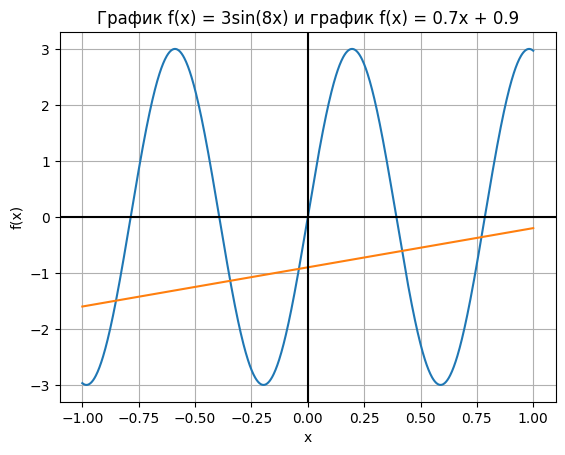

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return 3*np.sin(8*x)
def fa(x):
    return 0.7*x - 0.9
x = np.linspace(-1, 1, 1000)
y = f(x)
xa = np.linspace(-1, 1, 1000)
ya = fa(xa)

plt.plot(x, y, xa, ya)
plt.axhline(y=0, color='k', linestyle='-')
plt.axvline(x=0, color='k', linestyle='-')
plt.grid(True)
plt.title('График f(x) = 3sin(8x) и график f(x) = 0.7x + 0.9')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.show()


Точки пересечения:
х1 ≈ -0.85;
х2 ≈ -0.41;
х3 ≈ -0.15;
х4 ≈ 0.41;
х5 ≈ 0.65.
С ручым спообом всё сходится   

### 2-е задание

In [ ]:
from math import *
def bisection(f, a, b, eps):
    if f(a) * f(b) >= 0:
        return None
    while (b - a) / 2 > eps:
        c = (a + b) / 2
        if f(c) == 0:
            return c
        if f(a) * f(c) < 0:
            b = c
        else:
            a = c
    return (a + b) / 2

def f(x):
    return 3*sin(8*x) - 0.7*x + 0.9

Answer = bisection(f, -0.4, -0.2, 1e-3)
print(Answer)  # должно выйти ≈ -0.3469

-0.34453125


Я решил взять точку на интервале [-0,4; -0,2] - это второй корень. Ответ программнымспособом сходится с ручным.

### 3-е задаие

In [ ]:
from math import *

def phi(x):
    """Итерационная функция x = (30/7)*sin(8x) + 9/7"""
    return (1/8) * asin((0.7*x - 0.9)/3)

def fixed_iteration(x0, eps, max_iter=10):
    """
    Метод простой итерации
    x0 - начальное приближение
    eps - требуемая точность
    max_iter - максимальное число итераций
    """
    x = x0
    print(f"{'Итерация ;      '}  {'x_n ;        '}  {'x_(n+1) ;    '}  {'|x_(n+1)-x_n| ;'}")
    print("-" * 75)

    for i in range(max_iter + 1):
        x_next = phi(x)
        end = abs(x_next - x)
        print(f"{i} | {x} | {x_next} | {end}")

        if end < eps:
            print(f"\nДостигнута точность {eps} за {i} итераций")
            return x_next
        x = x_next

    print(f"\nМаксимальное число итераций ({max_iter}) достигнуто")
    return x

# Выбираем начальное приближение из интервала [-0.35; -0.3]
x0 = -0.325

print("Метод простой итерации для уравнения: 3sin(8x) = 0.7x - 0.9")
print(f"Начальное приближение: x0 = {x0}")
print(f"Итерационная функция: φ(x) = (1/8) * asin((0.7*x - 0.9)/3)\n")

Answer = fixed_iteration(x0, 10**(-6))

print(f"\nРезультат: x ≈ {Answer:.7f}")

Метод простой итерации для уравнения: 3sin(8x) = 0.7x - 0.9
Начальное приближение: x0 = -0.325
Итерационная функция: φ(x) = (1/8) * asin((0.7*x - 0.9)/3)

Итерация ;        x_n ;          x_(n+1) ;      |x_(n+1)-x_n| ;
---------------------------------------------------------------------------
0 | -0.325 | -0.04816198390857614 | 0.2768380160914239
1 | -0.04816198390857614 | -0.03956190540837798 | 0.008600078500198165
2 | -0.03956190540837798 | -0.039298051176775727 | 0.00026385423160225213
3 | -0.039298051176775727 | -0.03928995888099937 | 8.092295776356007e-06
4 | -0.03928995888099937 | -0.03928971069646109 | 2.4818453828179265e-07

Достигнута точность 1e-06 за 4 итераций

Результат: x ≈ -0.0392897


Выбираем начальное приближение из интервала [-0.35; -0.3]. Начальное приближение: x0 = -0.325. Сравнивая с ручным способом, всё сходится,но ручным способом у меня вышло за 9 итерций

### 4-е задание

только метод касательных

In [ ]:
from math import *
def n(f1, f2, x0, eps, iter=1000):
    x = x0
    for i in range(iter):
        fx = f1(x)
        dfx = f2(x)
        x_new = x - fx/dfx
        x = x_new
        if abs(x_new - x) < eps:
            return x_new
        x = x_new
    return x

def f1(x):
    return 3*sin(8*x) - 0.7*x + 0.9

def f2(x):
    return 24*cos(8*x) - 0.7

Answer = n(f1, f2, -0.35, 10**(-6))
print('х = ',round( Answer, 7))  # ≈ -0.34394

х =  -0.3439933


комбинированый метод

In [3]:
from math import *
def f(x):
  y = 3*sin(8*x) - 0.7*x + 0.9
  return y
x1 = -0.35
x2 = -0.3
eps = 10**(-6)
d = (x1-x2)/2
n = 0
c = x1
print(f'n = {n}   x1 = {x1}   xr = {x2}')
while abs(d) > eps:
  x1 = round(x1 - f(x1)/(3*x1**2 + 6*x1 - 24), 6)
  x2 = round((c*f(x2) - x2*f(c))/(f(x2) - f(c)), 6)
  y = (x1+x2)/2
  d = (x1-x2)/2
  n += 1
  print(f'n = {n}   xl = {x1}   xr = {x2}')
x = y
print(f'x = {x}  n = {n}')

n = 0   x1 = -0.35   xr = -0.3
n = 1   xl = -0.344558   xr = -0.343372
n = 2   xl = -0.344007   xr = -0.343935
n = 3   xl = -0.343948   xr = -0.34394
n = 4   xl = -0.343941   xr = -0.34394
x = -0.3439405  n = 4
